# Data2001 - Assignment 1: Group 59

## Members:

1. SID: 520447042
2. SID:
3. SID:
4. SID: 

# Task 1:

In [85]:
import pandas as pd
import numpy as np

## Task 1.1: Load CSV File - COMPLETE

In [86]:
# Read in CSV and assign a name to the Series:
region = pd.read_csv("data/Region_summary_ New_South_ Wales_STE_1.csv")

## Task 1.2: Data Cleaning - TODO

### 1.2.1 Explore Raw Dataframe 

In [87]:
# Check DataFrame structure and info:
print("Dataframe Information Raw:")
print("Indices: \n\t", region.index)
print("Columns: \n\t", region.columns)
print("Shape: \n\t", region.shape)
print("Axes: \n\t", region.axes)
print("Data type: \n", region.dtypes)

Dataframe Information Raw:
Indices: 
	 RangeIndex(start=0, stop=800, step=1)
Columns: 
	 Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')
Shape: 
	 (800, 15)
Axes: 
	 [RangeIndex(start=0, stop=800, step=1), Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')]
Data type: 
 Measure Code           object
Parent Description     object
Description            object
2011                  float64
2015                  float64
2016                  float64
2017                  float64
2018                  float64
2019                  float64
2020                  float64
2021                  float64
2022                  float64
2023                  float64
2024                  float64
2025                  

### 1.2.2 Reformat data into long format

In [88]:
# Convert data into long format
# Where Year and Value have their own respecive columns.
region_long = region.melt(
    id_vars=["Measure Code", "Parent Description", "Description"], var_name="Year",value_name="Value"
)

### 1.2.3 Clean the Raw Data:

In [103]:
count_non_missing = region_long.groupby("Year")["Value"].count()
total_rows = region_long.groupby("Year")["Value"].size()

missing = total_rows - count_non_missing
print("Number of missing entries per year:\n",missing)

Number of missing entries per year:
 Year
2011    541
2015    780
2016    343
2017    752
2018    675
2019    530
2020    509
2021    108
2022    507
2023    593
2024    591
2025    797
Name: Value, dtype: int64


In [104]:
#Check for Missing values:
# 6726 missing values
print(region_long.isna().sum())

Measure Code             0
Parent Description       0
Description              0
Year                     0
Value                 6726
dtype: int64


In [105]:
#Check if there are any duplicates 
print(region_long.duplicated().sum())

0


In [106]:
# Drop rows with missing values
# Missing values represent unavailable data, not zero population which is why rows with missing values were removed for analysis.
region_clean = region_long.dropna(subset=["Value"], ignore_index=True).copy() # drop the rows with missing values
region_clean.name="NSW Regions"

In [107]:
print(region_clean.isna().sum())

Measure Code          0
Parent Description    0
Description           0
Year                  0
Value                 0
dtype: int64


In [108]:
# Convert object "Year" to Integer: 
region_clean['Year'] = region_clean['Year'].astype(int)

### 1.2.4 Explore Cleaned Dataframe

In [109]:
# Check DataFrame structure and info:
print("Dataframe Information - Clean:")
print("name: \n\t",region_clean.name)
print("Indices: \n\t", region_clean.index)
print("Columns: \n\t", region_clean.columns.tolist())
print("Shape: \n\t", region_clean.shape)
print("Axes: \n\t", region_clean.axes)
print("Data type: \n", region_clean.dtypes)

Dataframe Information - Clean:
name: 
	 NSW Regions
Indices: 
	 RangeIndex(start=0, stop=2874, step=1)
Columns: 
	 ['Measure Code', 'Parent Description', 'Description', 'Year', 'Value']
Shape: 
	 (2874, 5)
Axes: 
	 [RangeIndex(start=0, stop=2874, step=1), Index(['Measure Code', 'Parent Description', 'Description', 'Year', 'Value'], dtype='object')]
Data type: 
 Measure Code           object
Parent Description     object
Description            object
Year                    int64
Value                 float64
dtype: object


In [114]:
region_clean.sample(10)

,Measure Code,Parent Description,Description,Year,Value
2184,ERP_M_15,Estimated resident population - Males - year e...,Males - 65-69 years (no.),2022,199400.0
789,INSOLV_3,Debtors entering personal insolvencies - year ...,Debtors entering non-business related personal...,2018,7325.0
2325,CABEE_43,Number of businesses by turnover - at 30 June,Number of businesses with turnover of $50k to ...,2022,276036.0
547,TENURE_2,Tenure type - Occupied private dwellings - Census,Owned outright (%),2016,32.2
1277,ERP_P_19,Estimated resident population - Persons - year...,Persons - 85 and over (no.),2020,175306.0
759,DWELLSTOCK_13,Estimated dwelling stock - as at June quarter,Total dwellings (no.),2017,3112186.0
2495,ERP_M_34,Estimated resident population - Males - year e...,Males - 65-69 years (%),2023,4.9
2563,ERP_P_30,Estimated resident population - Persons - year...,Persons - 45-49 years (%),2023,6.0
1801,AGRIC_17,Gross value of agricultural production - year ...,Livestock slaughtered and other disposals - to...,2021,5044.7
2290,CABEE_3,Number of businesses - at 30 June,Number of employing businesses: 1-4 employees,2022,272838.0


In [112]:
# List the Parent Descriptions of the data set for reference
region_clean['Parent Description'].unique()

array(['Aboriginal and Torres Strait Islander Peoples - Census',
       'Religious affiliation - Census',
       'Australian citizenship - Census',
       'Speaks a language other than English at home - Census',
       'Estimated resident Aboriginal and Torres Strait Islander population - at 30 June',
       'Estimated resident Aboriginal and Torres Strait Islander population - Males - at 30 June',
       'Estimated resident Aboriginal and Torres Strait Islander population - Females - at 30 June',
       'Estimated resident Aboriginal and Torres Strait Islander population - Persons - at 30 June',
       'Language - Census',
       'Engagement in employment, education or training - Census',
       'Labour force status - Census',
       'Unpaid assistance to a person with a disability - Census',
       'Unpaid child care - Census',
       'Voluntary work for an organisation or group - Census',
       'Tenure type - Census',
       'Homelessness - Census estimates of homelessness',
      

## Task 1.3: Derived Statistics - TODO

### Group member 1 SID: 520447042

#### Stat 1: Number of jobs Held by Males and Females

In [184]:
#Grab subset of data from region
leed_data = region_clean[region_clean["Measure Code"].str.contains('LEED')].copy()

In [227]:
woman_jobs = []
men_jobs = []
most_indust = []

woman_jobs = leed_data[leed_data['Description'] == 'Number of jobs held by females'].groupby('Year')['Value'].sum()
men_jobs = leed_data[leed_data['Description'] == 'Number of jobs held by males'].groupby('Year')['Value'].sum()

# most_indust = leed_data[
#     leed_data['Description'].str.contains('Number of employee jobs -')
# ].groupby(['Year', 'Description'])['Value'].sum()

print("Result:")
print(f"The mean for the most jobs held by females between the years {woman_jobs.idxmin()} - {woman_jobs.idxmax()} was {woman_jobs.mean()} jobs. " 
      f"The lowest jobs held was during {woman_jobs.idxmin()} with {woman_jobs.min()} " 
      f"where as the most was in {woman_jobs.idxmax()} with {woman_jobs.max()}")
print(f"The men on the other hand have a mean for jobs held for the same period of {men_jobs.mean()} jobs. " 
      f"The lowest was during {men_jobs.idxmin()} with {men_jobs.min()} jobs " 
      f"and as the most was in {men_jobs.idxmax()} with {men_jobs.max()}")


Result:
The mean for the most jobs held by females between the years 2018 - 2022 was 3149047.8 jobs. The lowest jobs held was during 2018 with 2995986.0 where as the most was in 2022 with 3446628.0
The men on the other hand have a mean for jobs held for the same period of 3314007.8 jobs. The lowest was during 2018 with 3220689.0 jobs and as the most was in 2022 with 3519659.0


#### Stat 2: to finish

Text(0.5, 1.0, 'Num of Jobs in Aus - accommodation & food services 2018-2022')

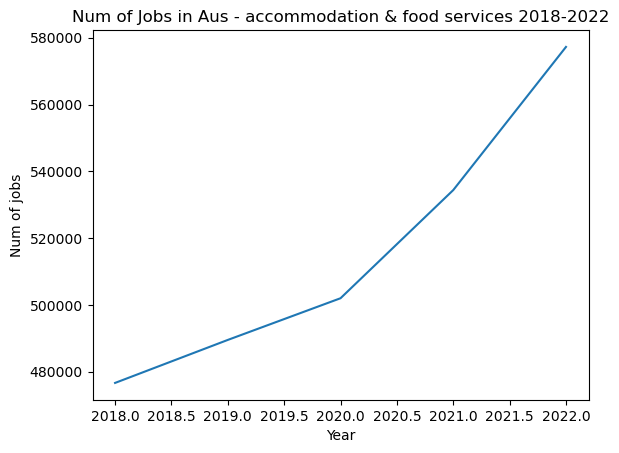

In [190]:
# Plot the mean values for each year.
plot = region_clean[
    region_clean["Measure Code"] == "LEED_12"
].groupby("Year")["Value"].mean().plot()

plot.set_xlabel("Year")
plot.set_ylabel("Num of jobs")
plot.set_title("Num of Jobs in Aus - accommodation & food services 2018-2022")

#### Stat 3: to finish

In [92]:
print(region_clean[region_long_clean["Measure Code"] == "CENSUS_34"])

     Measure Code                                 Parent Description  \
0       CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   
279     CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   
1597    CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   

                                            Description  Year     Value  
0     Aboriginal and Torres Strait Islander Peoples ...  2011  172620.0  
279   Aboriginal and Torres Strait Islander Peoples ...  2016  216171.0  
1597  Aboriginal and Torres Strait Islander Peoples ...  2021  278043.0  


#### Stat 4: to finish

#### Stat 5: to finish

### Group member 2 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

#### Stat 5:

### Group member 3 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

In [59]:
#### Stat 5:

### Group member 4 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

#### Stat 5:

# Task 2: API Data Collection - TO DO

## Task 2: Load in NSW Points of Interest API - TO DO

### Link to the API website: https://datasets.seed.nsw.gov.au/dataset/nsw-points-of-interest-poi

1. isolate an area box using longtitude and latitude
2. Find all POIs in chosen area
3. do analysis (check all these as i am doing this from memory)

## Task 2: Develop Function - TO DO

## Task 2: Build Loop - TO DO

## Task 2: Add results to Database - TO DO

# Task 3: Compute Scores - TO DO

# Task 4: Prepare Report - TO DO

# Task 5: Brief Conversation with Tutor - TO DO

# Deliverables - TO DO

1. PDF Report  - Google Doc: link in READ ME and : https://docs.google.com/document/d/1n2X06f8SsJrVs9xzTqE0d5J3EYx_cJwz28PFvmnBcf0/edit?usp=sharing
2. Juytper Notebook - THIS
3. Convo with tutor

In [38]:
region_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        9600 non-null   object 
 1   Parent Description  9600 non-null   object 
 2   Description         9600 non-null   object 
 3   Year                9600 non-null   object 
 4   Value               2874 non-null   float64
dtypes: float64(1), object(4)
memory usage: 375.1+ KB
